In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
import os 
exp_names = sorted(os.listdir("/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"))
exp_names = [exp_name for exp_name in exp_names if "DiT" in exp_name]

In [ ]:
import sys
sys.path.append("/n/home12/binxuwang/Github/DiffusionAttnConsistency")
from scripts.parity_memorization_eval_cli import evaluate_experiment_memorization

exp_name = "DiT_mini_parity_N8192_D36_G4_even"
for exp_name in [
        "DiT_mini_parity_N8192_D36_G9_even",
        ]:
    mem_eval_stats_df = evaluate_experiment_memorization(exp_name, incremental=True, skip_completed=True, save_plot=False)

/n/home12/binxuwang/Github/circuit_toolkit/circuit_toolkit/GAN_invert_utils.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange, tqdm


Evaluating experiment: DiT_mini_parity_N8192_D36_G9_even
Parameters: 8192 samples, 36 bits per sample, 9 bits per group
Found 1471 evaluation steps: 1 to 1000000
Found existing results for 1471 steps
Incremental mode: processing 0 new steps
Starting with 1471 existing results
No new steps to process
Saved evaluation statistics to /n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning/DiT_mini_parity_N8192_D36_G9_even/mem_eval_stats.csv


In [7]:
import sys
import pandas as pd
from os.path import join
from easydict import EasyDict as edict
import json
sys.path.append("/n/home12/binxuwang/Github/DiffusionAttnConsistency")
from scripts.parity_memorization_eval_cli import evaluate_experiment_memorization

# exp_name = "DiT_mini_parity_N8192_D36_G4_even" 
saveroot = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
mem_eval_syn_col = []
for exp_name in exp_names:
    savedir = join(saveroot, exp_name)
    # Load experiment metadata
    args = edict(json.load(open(f"{savedir}/args.json")))
    config = json.load(open(f"{savedir}/config.json"))
    # Extract experiment parameters
    train_sample_num = args.sample_num
    sample_len = args.sample_len
    group_size = args.group_size
    parity = args.parity
    num_groups = sample_len // group_size
    nlayer = config["depth"]
    nhead = config["num_heads"]
    print(f"Parameters: {train_sample_num} samples, {sample_len} bits per sample, {group_size} bits per group")
    mem_eval_stats_df = evaluate_experiment_memorization(exp_name, incremental=True, skip_completed=True, save_plot=False)
    mem_eval_stats_df["exp_name"] = exp_name
    mem_eval_stats_df["train_sample_num"] = train_sample_num
    # mem_eval_stats_df["sample_len"] = sample_len
    mem_eval_stats_df["group_size"] = group_size
    # mem_eval_stats_df["parity"] = parity
    mem_eval_stats_df["num_groups"] = num_groups
    mem_eval_stats_df["DiT_nlayer"] = nlayer
    mem_eval_stats_df["DiT_nhead"] = nhead
    mem_eval_syn_col.append(mem_eval_stats_df)
    print(f"Evaluated {exp_name}")

mem_eval_syn_df = pd.concat(mem_eval_syn_col, axis=0) # concat all the dataframes
mem_eval_syn_df.to_csv(join(saveroot, "mem_eval_synopsis.csv"), index=False)

Parameters: 4096 samples, 36 bits per sample, 12 bits per group
Evaluating experiment: DiT_B_parity_N4096_D36_G12_even
Parameters: 4096 samples, 36 bits per sample, 12 bits per group
Found 1217 evaluation steps: 1 to 740000
Found existing results for 972 steps
Incremental mode: processing 245 new steps
Starting with 972 existing results


Step 740000: mem_ratio 0.689, bitgroup_mem_ratio 0.859, parity_acc 0.858, sample_acc 0.722: 100%|██████████| 245/245 [00:09<00:00, 24.76it/s]


Saved evaluation statistics to /n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning/DiT_B_parity_N4096_D36_G12_even/mem_eval_stats.csv
Evaluated DiT_B_parity_N4096_D36_G12_even
Parameters: 4096 samples, 36 bits per sample, 18 bits per group
Evaluating experiment: DiT_B_parity_N4096_D36_G18_even
Parameters: 4096 samples, 36 bits per sample, 18 bits per group
Found 1210 evaluation steps: 1 to 732832
Found existing results for 967 steps
Incremental mode: processing 243 new steps
Starting with 967 existing results


Step 732832: mem_ratio 0.809, bitgroup_mem_ratio 0.857, parity_acc 0.900, sample_acc 0.838: 100%|██████████| 243/243 [00:09<00:00, 26.45it/s]


Saved evaluation statistics to /n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning/DiT_B_parity_N4096_D36_G18_even/mem_eval_stats.csv
Evaluated DiT_B_parity_N4096_D36_G18_even
Parameters: 4096 samples, 36 bits per sample, 2 bits per group
Evaluating experiment: DiT_B_parity_N4096_D36_G2_even
Parameters: 4096 samples, 36 bits per sample, 2 bits per group
Found 1215 evaluation steps: 1 to 737952
Found existing results for 969 steps
Incremental mode: processing 246 new steps
Starting with 969 existing results


...

Saved evaluation statistics to /n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning/DiT_B_parity_N4096_D36_G4_even/mem_eval_stats.csv
Evaluated DiT_B_parity_N4096_D36_G4_even
Parameters: 4096 samples, 36 bits per sample, 6 bits per group
Evaluating experiment: DiT_B_parity_N4096_D36_G6_even
Parameters: 4096 samples, 36 bits per sample, 6 bits per group
Found 1214 evaluation steps: 1 to 736928
Found existing results for 969 steps
Incremental mode: processing 245 new steps
Starting with 969 existing results


Step 736928: mem_ratio 0.559, bitgroup_mem_ratio 0.986, parity_acc 0.986, sample_acc 0.919: 100%|██████████| 245/245 [00:09<00:00, 26.52it/s]


Saved evaluation statistics to /n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning/DiT_B_parity_N4096_D36_G6_even/mem_eval_stats.csv
Evaluated DiT_B_parity_N4096_D36_G6_even
Parameters: 4096 samples, 36 bits per sample, 9 bits per group
Evaluating experiment: DiT_B_parity_N4096_D36_G9_even
Parameters: 4096 samples, 36 bits per sample, 9 bits per group
Found 1221 evaluation steps: 1 to 744096
Found existing results for 974 steps
Incremental mode: processing 247 new steps
Starting with 974 existing results


Step 744096: mem_ratio 0.706, bitgroup_mem_ratio 0.883, parity_acc 0.879, sample_acc 0.720: 100%|██████████| 247/247 [00:09<00:00, 26.92it/s]


Saved evaluation statistics to /n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning/DiT_B_parity_N4096_D36_G9_even/mem_eval_stats.csv
Evaluated DiT_B_parity_N4096_D36_G9_even
Parameters: 4096 samples, 36 bits per sample, 12 bits per group
Evaluating experiment: DiT_S_parity_N4096_D36_G12_even
Parameters: 4096 samples, 36 bits per sample, 12 bits per group
Found 1472 evaluation steps: 1 to 1000000
Found existing results for 1472 steps
Incremental mode: processing 0 new steps
Starting with 1472 existing results
No new steps to process
Saved evaluation statistics to /n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning/DiT_S_parity_N4096_D36_G12_even/mem_eval_stats.csv
Evaluated DiT_S_parity_N4096_D36_G12_even
Parameters: 4096 samples, 36 bits per sample, 18 bits per group
Evaluating experiment: DiT_S_parity_N4096_D36_G18_even
Parameters: 4096 samples, 36 bits per sample, 18 bits per group
Found 1472 evalua

In [8]:
mem_eval_syn_df.shape

(103923, 20)

In [9]:
mem_eval_syn_df.head()

,step,sample_mem_num,sample_mem_ratio,bitgroup_mem_num,bitgroup_mem_ratio,sample_num,group_size,nan_num_eps_1e-1,nan_ratio_eps_1e-1,nan_num_eps_1e-2,nan_ratio_eps_1e-2,pergroup_parity_num,pergroup_parity_acc,sample_corr_num,sample_corr_acc,exp_name,train_sample_num,num_groups,DiT_nlayer,DiT_nhead
0,1,0,0.0,4061,0.660970,2048,12,2048,1.0,2048,1.0,0,0.0,0,0.0,DiT_B_parity_N4096_D36_G12_even,4096,3,12,12
1,2,0,0.0,3938,0.640951,2048,12,2048,1.0,2048,1.0,0,0.0,0,0.0,DiT_B_parity_N4096_D36_G12_even,4096,3,12,12
2,3,0,0.0,3863,0.628743,2048,12,2048,1.0,2048,1.0,0,0.0,0,0.0,DiT_B_parity_N4096_D36_G12_even,4096,3,12,12
3,4,0,0.0,3885,0.632324,2048,12,2048,1.0,2048,1.0,0,0.0,0,0.0,DiT_B_parity_N4096_D36_G12_even,4096,3,12,12
4,5,0,0.0,3870,0.629883,2048,12,2048,1.0,2048,1.0,0,0.0,0,0.0,DiT_B_parity_N4096_D36_G12_even,4096,3,12,12


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
65536 / 2**18

0.25

In [19]:
16384 / 2**18

0.0625

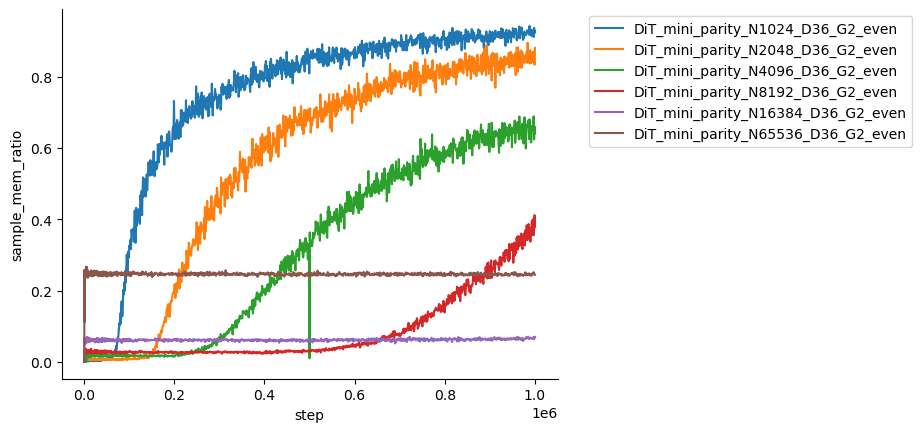

In [16]:
sns.lineplot(x="step", y="sample_mem_ratio", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 2").sort_values(by="train_sample_num"))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

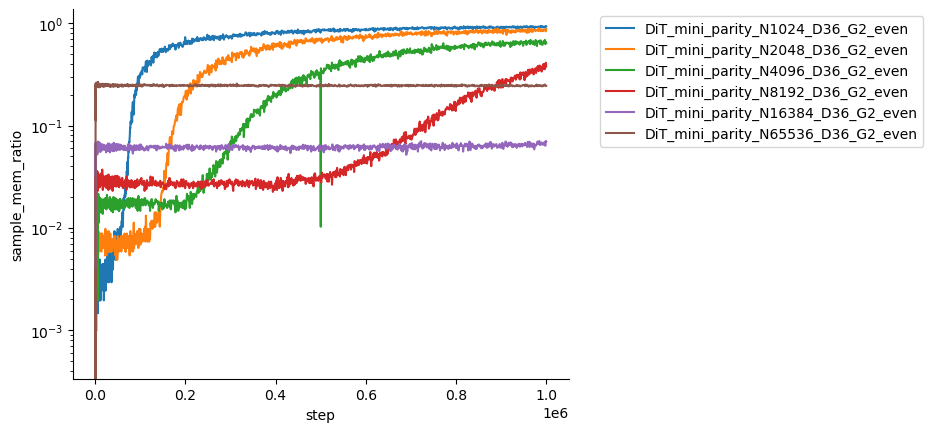

In [22]:
sns.lineplot(x="step", y="sample_mem_ratio", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 2").sort_values(by="train_sample_num"))
plt.yscale("log")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [41]:
group_size = 3
sample_total_possible_cnts = (2 ** group_size / 2) ** (36 // group_size)
65536 / sample_total_possible_cnts

0.00390625

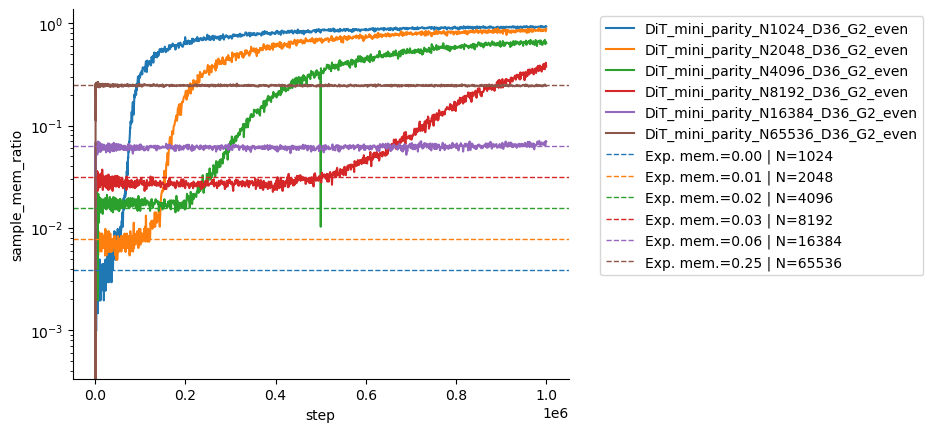

In [43]:
group_size = 2
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == @group_size").sort_values(by="train_sample_num")
sns.lineplot(x="step", y="sample_mem_ratio", hue="exp_name", 
             data=plot_df)
plt.yscale("log")

for i, train_sample_num in enumerate(plot_df["train_sample_num"].unique()):
    expected_mem_ratio = train_sample_num / (2 ** group_size / 2) ** (36 // group_size)
    plt.axhline(y=expected_mem_ratio, color=f"C{i}", linestyle="--", linewidth=1, label=f"Exp. mem.={expected_mem_ratio:.2f} | N={train_sample_num}")
    # plt.text(x=plot_df["step"].max(), y=expected_mem_ratio, s=f"{train_sample_num}", color="black", fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

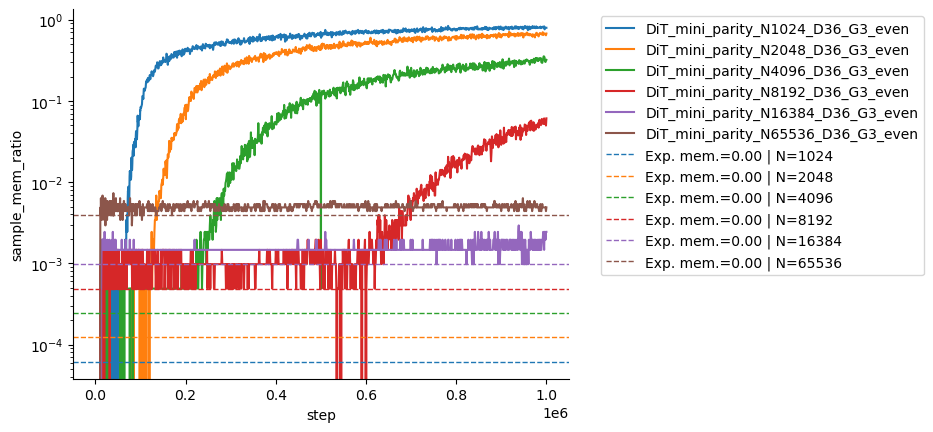

In [ ]:
group_size = 3
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == @group_size").sort_values(by="train_sample_num")
sns.lineplot(x="step", y="sample_mem_ratio", hue="exp_name", 
             data=plot_df)
plt.yscale("log")

for i, train_sample_num in enumerate(plot_df["train_sample_num"].unique()):
    expected_mem_ratio = train_sample_num / (2 ** group_size / 2) ** (36 // group_size)
    plt.axhline(y=expected_mem_ratio, color=f"C{i}", linestyle="--", linewidth=1, label=f"Exp. mem.={expected_mem_ratio:.2f} | N={train_sample_num}")
    # plt.text(x=plot_df["step"].max(), y=expected_mem_ratio, s=f"{train_sample_num}", color="black", fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

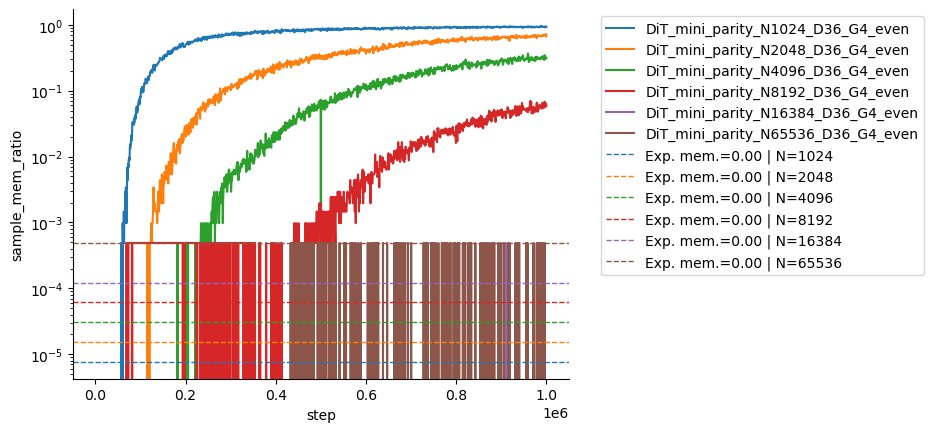

In [44]:
group_size = 4
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == @group_size").sort_values(by="train_sample_num")
sns.lineplot(x="step", y="sample_mem_ratio", hue="exp_name", 
             data=plot_df)
plt.yscale("log")

for i, train_sample_num in enumerate(plot_df["train_sample_num"].unique()):
    expected_mem_ratio = train_sample_num / (2 ** group_size / 2) ** (36 // group_size)
    plt.axhline(y=expected_mem_ratio, color=f"C{i}", linestyle="--", linewidth=1, label=f"Exp. mem.={expected_mem_ratio:.2f} | N={train_sample_num}")
    # plt.text(x=plot_df["step"].max(), y=expected_mem_ratio, s=f"{train_sample_num}", color="black", fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

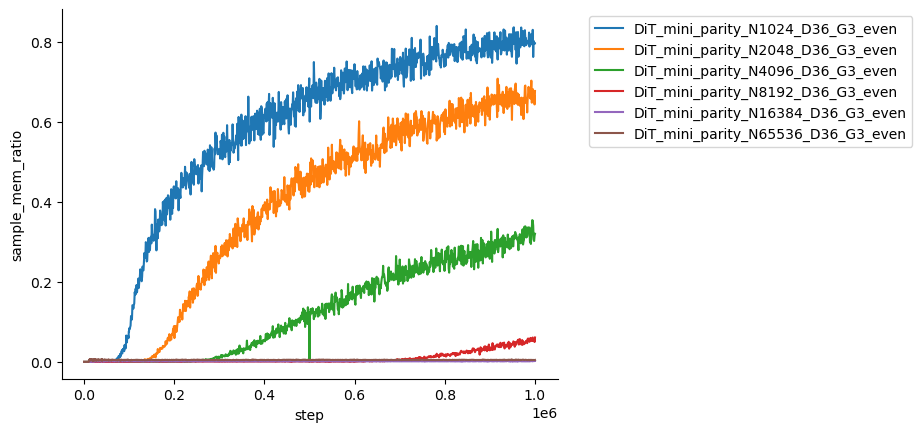

In [ ]:
sns.lineplot(x="step", y="sample_mem_ratio", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 3").sort_values(by="train_sample_num"))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

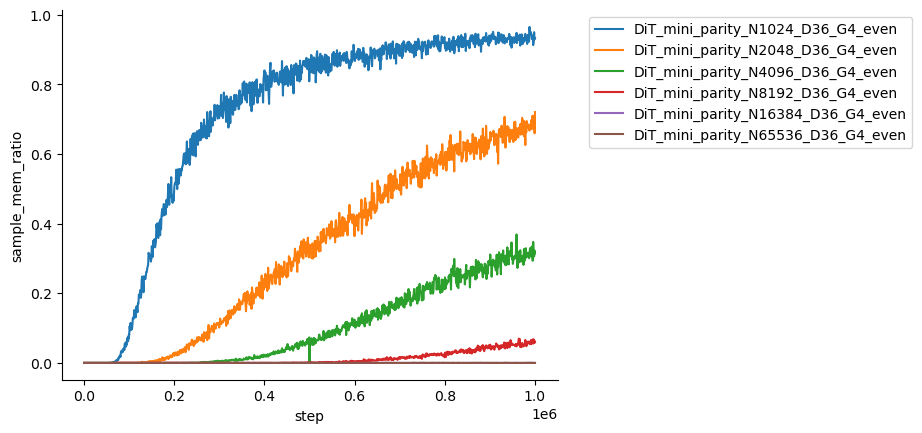

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x="step", y="sample_mem_ratio", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 4").sort_values(by="train_sample_num"))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [68]:
256 * 1E6 / 65536

3906.25

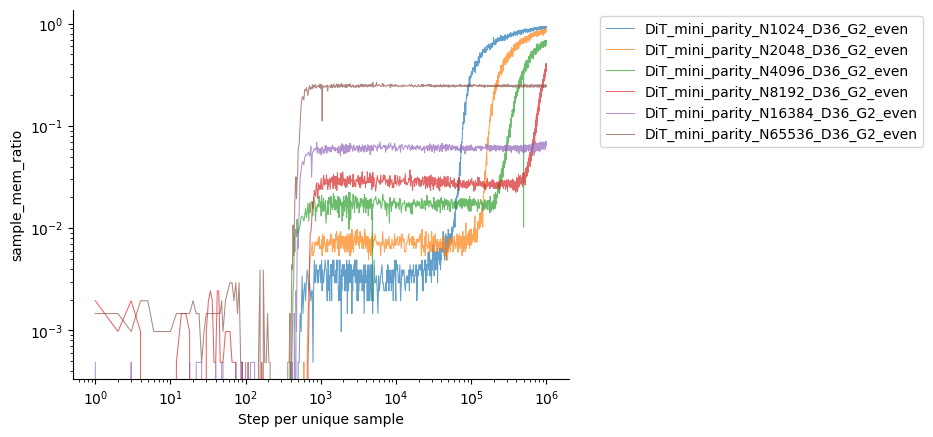

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt
train_batch_size = 256
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 2").sort_values(by="train_sample_num")
for exp_name in plot_df["exp_name"].unique():
    exp_df = plot_df.query("exp_name == @exp_name")
    train_sample_num = exp_df["train_sample_num"].unique()[0]
    sns.lineplot(x=exp_df["step"] , 
                 y=exp_df["sample_mem_ratio"], label=exp_name, alpha=0.7, linewidth=0.75)
    #  data=exp_df)
    # plt.text(x=exp_df["step"].max() / train_sample_num, y=exp_df["sample_mem_ratio"].max(), s=f"{exp_name}", color="black", fontsize=12)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step per unique sample")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

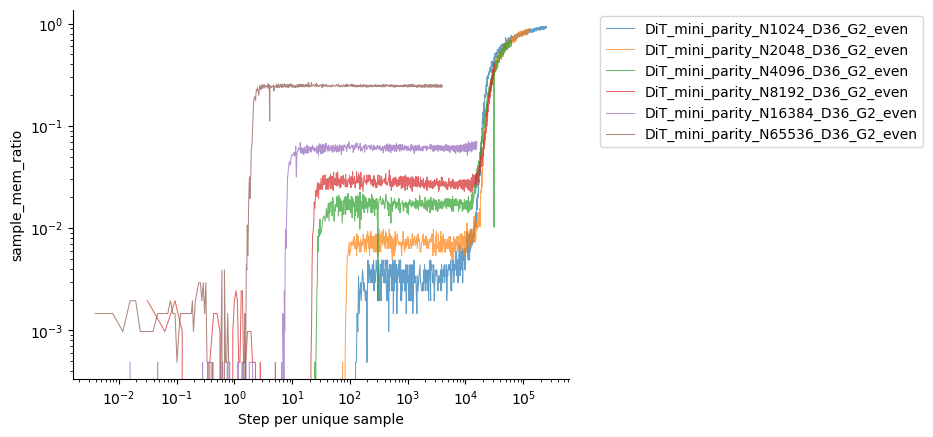

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
train_batch_size = 256
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 2").sort_values(by="train_sample_num")
for exp_name in plot_df["exp_name"].unique():
    exp_df = plot_df.query("exp_name == @exp_name")
    train_sample_num = exp_df["train_sample_num"].unique()[0]
    sns.lineplot(x=exp_df["step"] * train_batch_size / train_sample_num**1.0, 
                 y=exp_df["sample_mem_ratio"], label=exp_name, alpha=0.7, linewidth=0.75)
    #  data=exp_df)
    # plt.text(x=exp_df["step"].max() / train_sample_num, y=exp_df["sample_mem_ratio"].max(), s=f"{exp_name}", color="black", fontsize=12)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step per unique sample")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

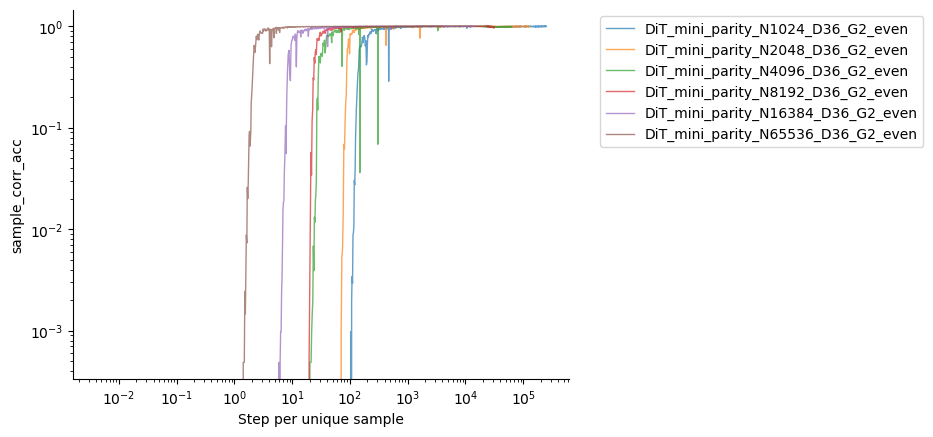

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt
train_batch_size = 256
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 2").sort_values(by="train_sample_num")
for exp_name in plot_df["exp_name"].unique():
    exp_df = plot_df.query("exp_name == @exp_name")
    train_sample_num = exp_df["train_sample_num"].unique()[0]
    sns.lineplot(x=exp_df["step"] * train_batch_size / train_sample_num**1.0, 
                 y=exp_df["sample_corr_acc"], label=exp_name, alpha=0.7, linewidth=1)
    #  data=exp_df)
    # plt.text(x=exp_df["step"].max() / train_sample_num, y=exp_df["sample_mem_ratio"].max(), s=f"{exp_name}", color="black", fontsize=12)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step per unique sample")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

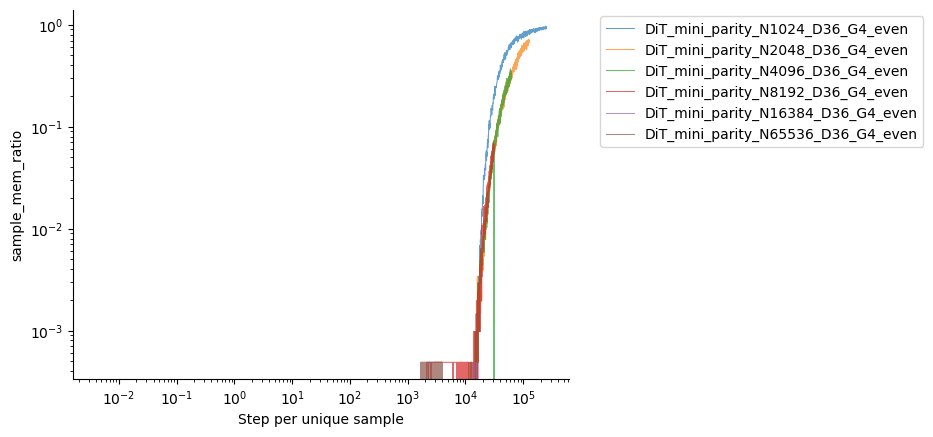

In [176]:
import seaborn as sns
import matplotlib.pyplot as plt
train_batch_size = 256
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 4").sort_values(by="train_sample_num")
for exp_name in plot_df["exp_name"].unique():
    exp_df = plot_df.query("exp_name == @exp_name")
    train_sample_num = exp_df["train_sample_num"].unique()[0]
    sns.lineplot(x=exp_df["step"] * train_batch_size / train_sample_num**1.0, 
                 y=exp_df["sample_mem_ratio"], label=exp_name, alpha=0.7, linewidth=0.75)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step per unique sample")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [78]:
exp_df.head()

,step,sample_mem_num,sample_mem_ratio,bitgroup_mem_num,bitgroup_mem_ratio,sample_num,group_size,nan_num_eps_1e-1,nan_ratio_eps_1e-1,nan_num_eps_1e-2,nan_ratio_eps_1e-2,pergroup_parity_num,pergroup_parity_acc,sample_corr_num,sample_corr_acc,exp_name,train_sample_num,num_groups,DiT_nlayer,DiT_nhead
42,100,0,0.0,9202,0.499240,2048,4,2048,1.000000,2048,1.0,2779,0.150770,0,0.000000,DiT_mini_parity_N65536_D36_G4_even,65536,9,6,6
43,108,0,0.0,10216,0.554253,2048,4,1998,0.975586,2048,1.0,4916,0.266710,0,0.000000,DiT_mini_parity_N65536_D36_G4_even,65536,9,6,6
44,116,0,0.0,9276,0.503255,2048,4,1583,0.772949,2048,1.0,7695,0.417480,2,0.000977,DiT_mini_parity_N65536_D36_G4_even,65536,9,6,6
45,124,0,0.0,9357,0.507650,2048,4,1516,0.740234,2048,1.0,7779,0.422038,4,0.001953,DiT_mini_parity_N65536_D36_G4_even,65536,9,6,6
30,54,0,0.0,15131,0.820909,2048,4,2048,1.000000,2048,1.0,0,0.000000,0,0.000000,DiT_mini_parity_N65536_D36_G4_even,65536,9,6,6


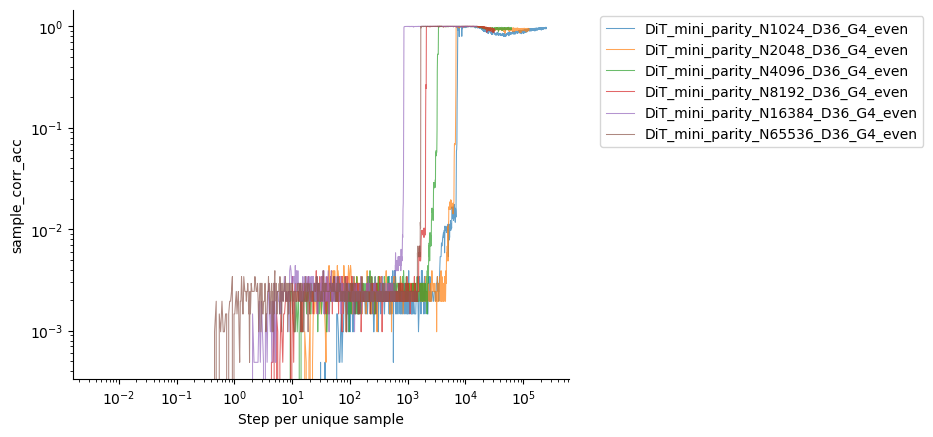

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
train_batch_size = 256
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 4").sort_values(by="train_sample_num")
for exp_name in plot_df["exp_name"].unique():
    exp_df = plot_df.query("exp_name == @exp_name")
    train_sample_num = exp_df["train_sample_num"].unique()[0]
    sns.lineplot(x=exp_df["step"] * train_batch_size / train_sample_num**1.0, 
                 y=exp_df["sample_corr_acc"], label=exp_name, alpha=0.7, linewidth=0.75)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step per unique sample")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

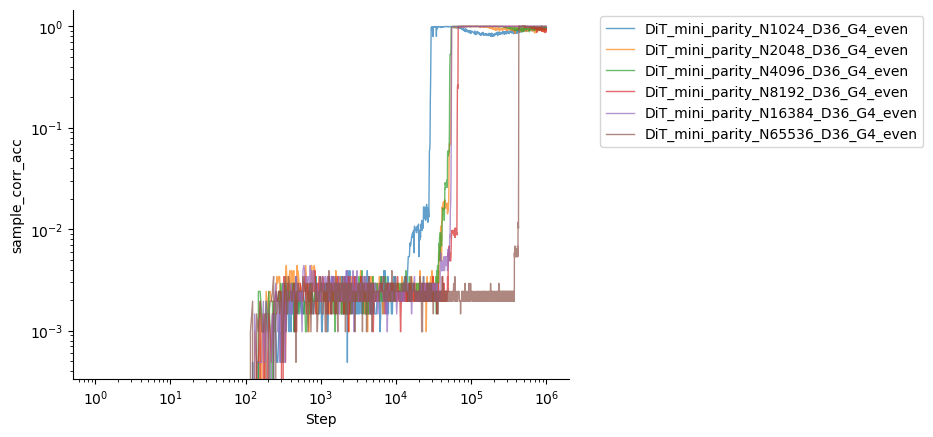

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
train_batch_size = 256
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 4").sort_values(by="train_sample_num")
for exp_name in plot_df["exp_name"].unique():
    exp_df = plot_df.query("exp_name == @exp_name")
    train_sample_num = exp_df["train_sample_num"].unique()[0]
    sns.lineplot(x=exp_df["step"], y=exp_df["sample_corr_acc"], label=exp_name, alpha=0.7, linewidth=1)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

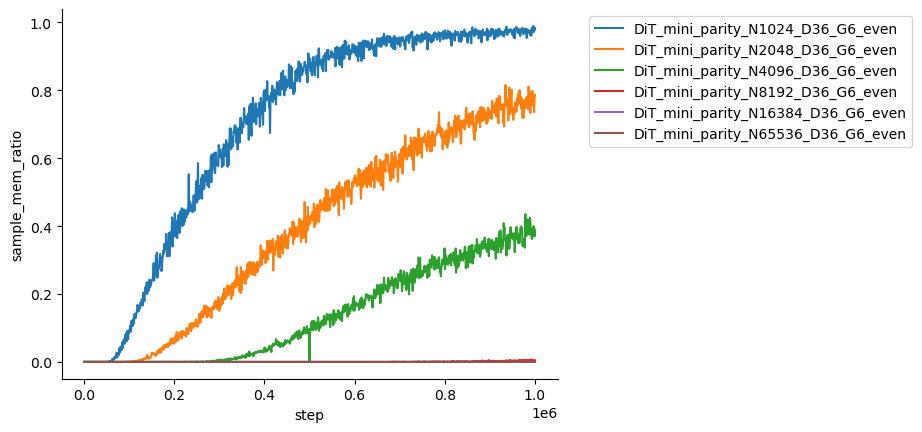

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x="step", y="sample_mem_ratio", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 6").sort_values(by="train_sample_num"))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

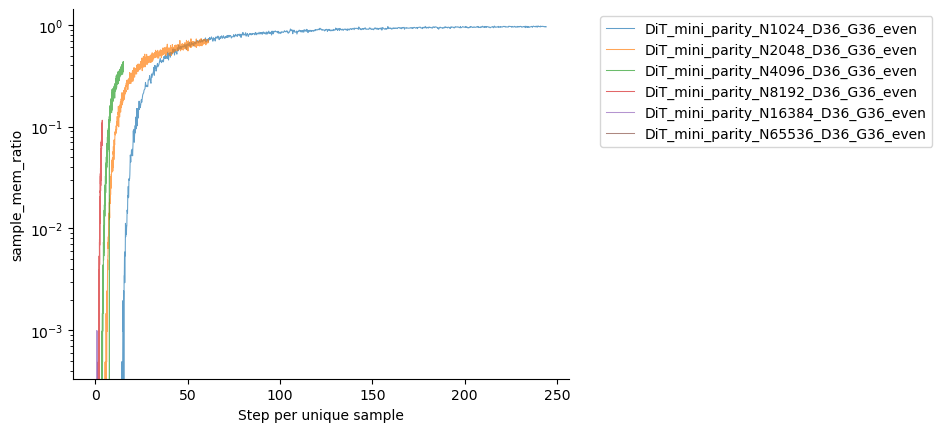

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt
train_batch_size = 256
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 36").sort_values(by="train_sample_num")
for exp_name in plot_df["exp_name"].unique():
    exp_df = plot_df.query("exp_name == @exp_name")
    train_sample_num = exp_df["train_sample_num"].unique()[0]
    sns.lineplot(x=exp_df["step"] * train_batch_size / train_sample_num**2, 
                 y=exp_df["sample_mem_ratio"], label=exp_name, alpha=0.7, linewidth=0.75)
# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step per unique sample")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

5.886121746618301 4.0
5.667716018622741 4.0
5.505805198219605 4.0
5.3664007051847875 4.0
5.164106877491577 2.8284270763397217
4.815942657507549 2.8284270763397217


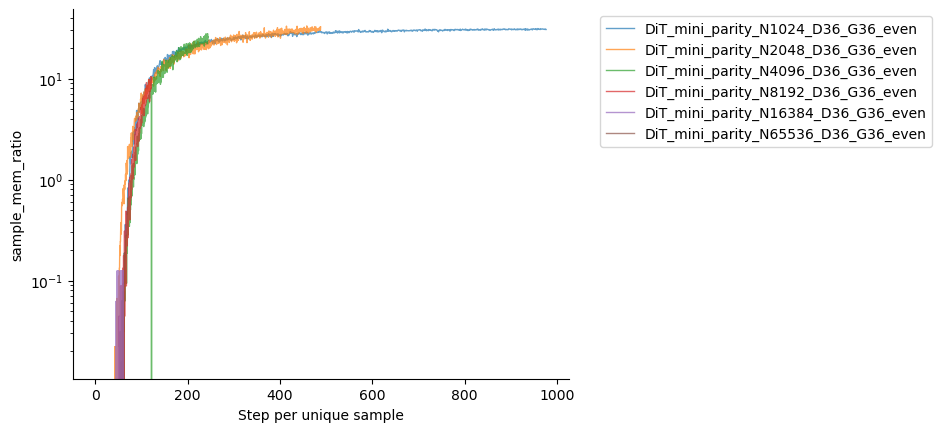

In [159]:
train_batch_size = 256
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 36").sort_values(by="train_sample_num")
for exp_name in plot_df["exp_name"].unique():
    exp_df = plot_df.query("exp_name == @exp_name")
    exp_mean_nn_distance = nn_analysis_df.query("exp_name == @exp_name").iloc[0, ]["mean_nn_distance"]
    exp_min_nn_distance = nn_analysis_df.query("exp_name == @exp_name").iloc[0, ]["min_nn_distance"]
    print(exp_mean_nn_distance, exp_min_nn_distance)
    train_sample_num = exp_df["train_sample_num"].unique()[0]
    sns.lineplot(x=exp_df["step"] / train_sample_num, 
                 y=exp_df["sample_mem_ratio"] * train_sample_num**0.5, label=exp_name, alpha=0.7, linewidth=1)
# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step per unique sample")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

5.854253882076591 4.898979663848877
5.6415226857643574 4.0
5.467189175658859 2.8284270763397217
5.29232917947229 2.8284270763397217
5.076402140664868 2.8284270763397217
4.724421965791407 2.8284270763397217


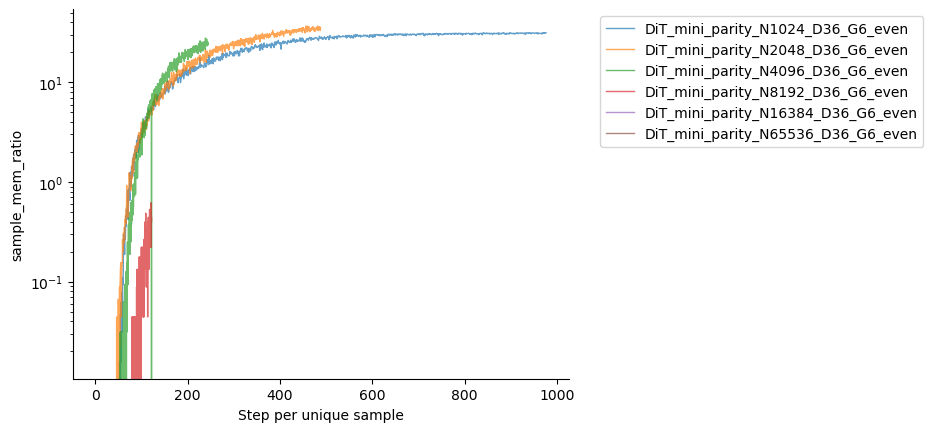

In [177]:
train_batch_size = 256
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 6").sort_values(by="train_sample_num")
for exp_name in plot_df["exp_name"].unique():
    exp_df = plot_df.query("exp_name == @exp_name")
    exp_mean_nn_distance = nn_analysis_df.query("exp_name == @exp_name").iloc[0, ]["mean_nn_distance"]
    exp_min_nn_distance = nn_analysis_df.query("exp_name == @exp_name").iloc[0, ]["min_nn_distance"]
    print(exp_mean_nn_distance, exp_min_nn_distance)
    train_sample_num = exp_df["train_sample_num"].unique()[0]
    sns.lineplot(x=exp_df["step"] / train_sample_num, 
                 y=exp_df["sample_mem_ratio"] * train_sample_num**0.5, label=exp_name, alpha=0.7, linewidth=1)
# plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step per unique sample")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [166]:
exp_df.head()

,step,sample_mem_num,sample_mem_ratio,bitgroup_mem_num,bitgroup_mem_ratio,sample_num,group_size,nan_num_eps_1e-1,nan_ratio_eps_1e-1,nan_num_eps_1e-2,nan_ratio_eps_1e-2,pergroup_parity_num,pergroup_parity_acc,sample_corr_num,sample_corr_acc,exp_name,train_sample_num,num_groups,DiT_nlayer,DiT_nhead
7,8,0,0.000000,33605,0.911594,2048,2,2048,1.0,2048,1.0,177,0.004801,0,0.0,DiT_mini_parity_N8192_D36_G2_even,8192,18,6,6
8,9,0,0.000000,33612,0.911784,2048,2,2048,1.0,2048,1.0,179,0.004856,0,0.0,DiT_mini_parity_N8192_D36_G2_even,8192,18,6,6
9,10,0,0.000000,33555,0.910238,2048,2,2048,1.0,2048,1.0,167,0.004530,0,0.0,DiT_mini_parity_N8192_D36_G2_even,8192,18,6,6
10,12,1,0.000488,33448,0.907335,2048,2,2048,1.0,2048,1.0,159,0.004313,0,0.0,DiT_mini_parity_N8192_D36_G2_even,8192,18,6,6
11,14,3,0.001465,33394,0.905870,2048,2,2048,1.0,2048,1.0,172,0.004666,0,0.0,DiT_mini_parity_N8192_D36_G2_even,8192,18,6,6


3.1920957345719216 2.8284270763397217
4.439209970048978 2.8284270763397217
4.812593021357316 2.8284270763397217
5.076402140664868 2.8284270763397217
5.160172384552425 2.8284270763397217
5.163360023929272 2.8284270763397217
5.171722382510779 2.8284270763397217
5.164106877491577 2.8284270763397217


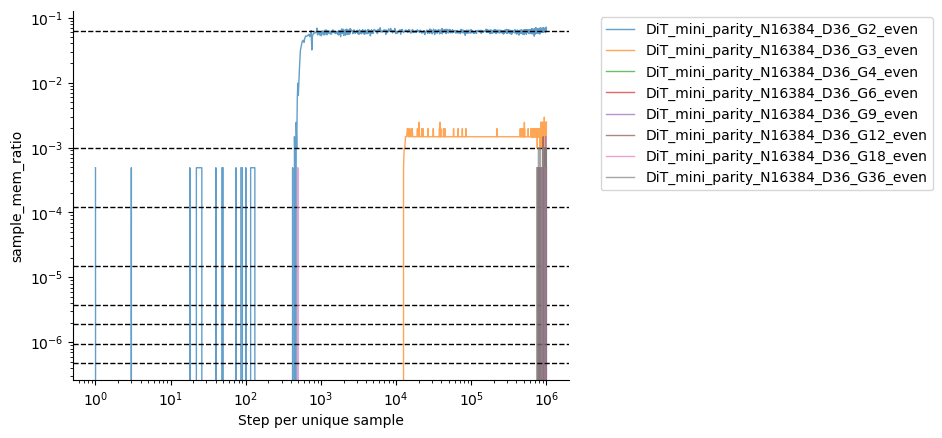

In [172]:
train_batch_size = 256
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and train_sample_num == 16384").sort_values(by="group_size")
for exp_name in plot_df["exp_name"].unique():
    exp_df = plot_df.query("exp_name == @exp_name")
    exp_mean_nn_distance = nn_analysis_df.query("exp_name == @exp_name").iloc[0, ]["mean_nn_distance"]
    exp_min_nn_distance = nn_analysis_df.query("exp_name == @exp_name").iloc[0, ]["min_nn_distance"]
    print(exp_mean_nn_distance, exp_min_nn_distance)
    train_sample_num = exp_df["train_sample_num"].unique()[0]
    group_size = exp_df["group_size"].unique()[0]
    sns.lineplot(x=exp_df["step"],  #  / train_sample_num
                 y=exp_df["sample_mem_ratio"], label=exp_name, alpha=0.7, linewidth=1) #  * train_sample_num**0.5
    exp_mem_ratio = train_sample_num / ( (2 ** group_size / 2) ** (36 // group_size) )
    plt.axhline(y=exp_mem_ratio, color="black", linestyle="--", linewidth=1)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step per unique sample")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

3.493279901216738 2.8284270763397217
4.67313174289302 2.8284270763397217
5.040542329661548 2.8284270763397217
5.29232917947229 2.8284270763397217
5.350826026580762 4.0
5.353472765593324 2.8284270763397217
5.349233794899192 2.8284270763397217
5.3664007051847875 4.0


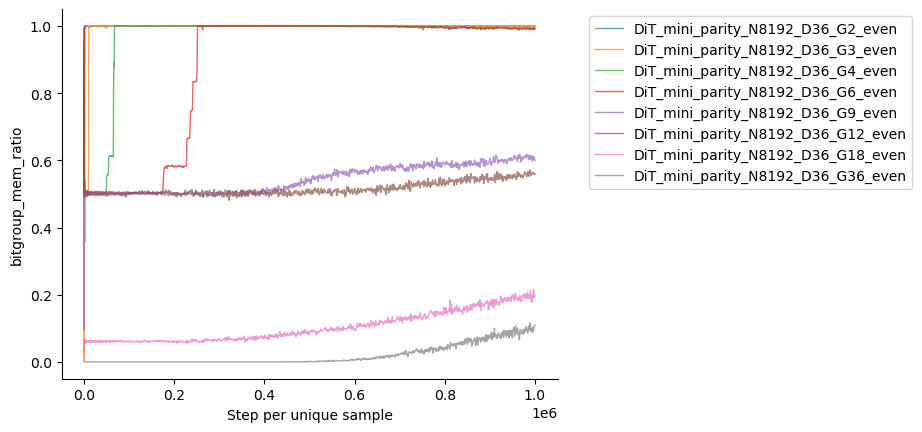

In [167]:
train_batch_size = 256
plot_df = mem_eval_syn_df.query("DiT_nlayer == 6 and train_sample_num == 8192").sort_values(by="group_size")
for exp_name in plot_df["exp_name"].unique():
    exp_df = plot_df.query("exp_name == @exp_name")
    exp_mean_nn_distance = nn_analysis_df.query("exp_name == @exp_name").iloc[0, ]["mean_nn_distance"]
    exp_min_nn_distance = nn_analysis_df.query("exp_name == @exp_name").iloc[0, ]["min_nn_distance"]
    print(exp_mean_nn_distance, exp_min_nn_distance)
    train_sample_num = exp_df["train_sample_num"].unique()[0]
    sns.lineplot(x=exp_df["step"],  #  / train_sample_num
                 y=exp_df["bitgroup_mem_ratio"], label=exp_name, alpha=0.7, linewidth=1) #  * train_sample_num**0.5
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Step per unique sample")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Measure critical spacing

In [129]:
DiT_mini_exp_names = [expname for expname in exp_names if "DiT_mini" in expname]

In [91]:
import numpy as np
import torch as th
from sklearn.neighbors import NearestNeighbors

def compute_nn_distances(data: th.Tensor, k: int = 1, metric: str = 'euclidean'):
    """
    Compute nearest neighbor distances for the training data.
    
    Args:
        data: Tensor of shape [N, D] containing training samples
        k: Number of nearest neighbors to consider (default: 1)
        metric: Distance metric ('euclidean', 'hamming', 'manhattan')
        
    Returns:
        dict: Statistics about nearest neighbor distances
    """
    N, D = data.shape
    print(f"Computing {k}-NN distances for {N} samples of dimension {D}")
    
    # Convert to numpy for sklearn
    data_np = data.cpu().numpy()
    
    # For binary data, use hamming distance
    if metric == 'hamming':
    # or th.all((data == -1) | (data == 1)):
        # Convert {-1, 1} to {0, 1} for hamming distance
        if th.all((data == -1) | (data == 1)):
            data_np = (data_np + 1) / 2
        metric = 'hamming'
        print("Using Hamming distance for binary data")
    
    # Fit nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=k+1, metric=metric, n_jobs=-1)
    nbrs.fit(data_np)
    
    # Find nearest neighbors (k+1 because first neighbor is the point itself)
    distances, indices = nbrs.kneighbors(data_np)
    
    # Remove self-distances (first column)
    nn_distances = distances[:, 1:k+1]
    
    # Compute statistics
    mean_nn_dist = np.mean(nn_distances)
    std_nn_dist = np.std(nn_distances)
    min_nn_dist = np.min(nn_distances)
    max_nn_dist = np.max(nn_distances)
    median_nn_dist = np.median(nn_distances)
    
    # For binary data with Hamming distance, convert back to bit differences
    if metric == 'hamming':
        mean_nn_dist *= D
        std_nn_dist *= D
        min_nn_dist *= D
        max_nn_dist *= D
        median_nn_dist *= D
        print(f"Converted Hamming distances to bit differences (multiply by {D})")
    
    return {
        'mean_nn_distance': mean_nn_dist,
        'std_nn_distance': std_nn_dist,
        'min_nn_distance': min_nn_dist,
        'max_nn_distance': max_nn_dist,
        'median_nn_distance': median_nn_dist,
        'num_samples': N,
        'dimension': D,
        'k_neighbors': k,
        'metric': metric
    }

In [94]:
# Analyze nearest neighbor distances for all experiments
nn_analysis_results = []
DiT_mini_exp_names = [expname for expname in exp_names if "DiT_mini" in expname]

for exp_name in DiT_mini_exp_names:
    try:
        print(f"\n=== Analyzing {exp_name} ===")
        savedir = join(saveroot, exp_name)
        
        # Load experiment metadata
        args = edict(json.load(open(f"{savedir}/args.json")))
        
        # Load training data
        training_data_path = f"{savedir}/training_data_tsr.pt"
        if not os.path.exists(training_data_path):
            print(f"Skip: Training data not found for {exp_name}")
            continue
            
        Xtsr = th.load(training_data_path, weights_only=False)
        print(f"Loaded training data shape: {Xtsr.shape}")
        
        # Flatten data for NN analysis
        data_flat = Xtsr.flatten(start_dim=1)
        
        # Compute nearest neighbor distances (using Hamming for binary data)
        nn_stats = compute_nn_distances(data_flat, k=1, metric='euclidean')
        
        # Add experiment metadata
        result = {
            'exp_name': exp_name,
            'train_sample_num': args.sample_num,
            'sample_len': args.sample_len,
            'group_size': args.group_size,
            'parity': args.parity,
            **nn_stats
        }
        # break
        nn_analysis_results.append(result)
        print(f"✓ Mean NN distance: {nn_stats['mean_nn_distance']:.3f} bits")
        
    except Exception as e:
        print(f"✗ Failed to analyze {exp_name}: {e}")
        continue

# Create DataFrame with results
nn_analysis_df = pd.DataFrame(nn_analysis_results)
print(f"\n=== COMPLETED ANALYSIS FOR {len(nn_analysis_df)} EXPERIMENTS ===")
nn_analysis_df.head()


=== Analyzing DiT_mini_parity_N1024_D36_G12_even ===
Loaded training data shape: torch.Size([1024, 1, 6, 6])
Computing 1-NN distances for 1024 samples of dimension 36
✓ Mean NN distance: 5.863 bits

=== Analyzing DiT_mini_parity_N1024_D36_G18_even ===
Loaded training data shape: torch.Size([1024, 1, 6, 6])
Computing 1-NN distances for 1024 samples of dimension 36
✓ Mean NN distance: 5.879 bits

=== Analyzing DiT_mini_parity_N1024_D36_G2_even ===
Loaded training data shape: torch.Size([1024, 1, 6, 6])
Computing 1-NN distances for 1024 samples of dimension 36
✓ Mean NN distance: 4.435 bits

=== Analyzing DiT_mini_parity_N1024_D36_G36_even ===
Loaded training data shape: torch.Size([1024, 1, 6, 6])
Computing 1-NN distances for 1024 samples of dimension 36
✓ Mean NN distance: 5.886 bits

=== Analyzing DiT_mini_parity_N1024_D36_G3_even ===
Loaded training data shape: torch.Size([1024, 1, 6, 6])
Computing 1-NN distances for 1024 samples of dimension 36
✓ Mean NN distance: 5.414 bits

=== An

,exp_name,train_sample_num,sample_len,group_size,parity,mean_nn_distance,std_nn_distance,min_nn_distance,max_nn_distance,median_nn_distance,num_samples,dimension,k_neighbors,metric
0,DiT_mini_parity_N1024_D36_G12_even,1024,36,12,0,5.863311,0.400802,4.898980,6.324555,5.656854,1024,36,1,euclidean
1,DiT_mini_parity_N1024_D36_G18_even,1024,36,18,0,5.878861,0.406884,4.000000,6.324555,5.656854,1024,36,1,euclidean
2,DiT_mini_parity_N1024_D36_G2_even,1024,36,2,0,4.435421,0.630357,2.828427,5.656854,4.898980,1024,36,1,euclidean
3,DiT_mini_parity_N1024_D36_G36_even,1024,36,36,0,5.886122,0.407518,4.000000,6.324555,5.656854,1024,36,1,euclidean
4,DiT_mini_parity_N1024_D36_G3_even,1024,36,3,0,5.414411,0.488713,2.828427,6.324555,5.656854,1024,36,1,euclidean


In [95]:
nn_analysis_df.to_csv("/n/home12/binxuwang/Github/DiffusionAttnConsistency/tables/parity_near_neighbor_stats_df.csv", index=False)

In [93]:
nn_stats

{'mean_nn_distance': 5.863311343360692,
 'std_nn_distance': 0.40080225571349715,
 'min_nn_distance': 4.898979663848877,
 'max_nn_distance': 6.324555397033691,
 'median_nn_distance': 5.656854152679443,
 'num_samples': 1024,
 'dimension': 36,
 'k_neighbors': 1,
 'metric': 'euclidean'}

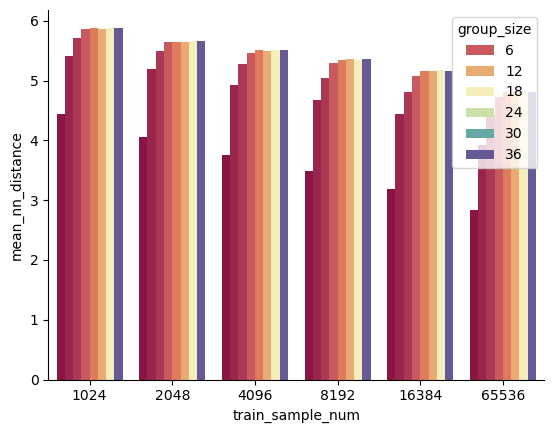

In [101]:
sns.barplot(x="train_sample_num", y="mean_nn_distance", hue="group_size", 
            data=nn_analysis_df, palette="Spectral", 
            hue_order=[2, 3, 4, 6, 9, 12, 18, 36])
plt.show()

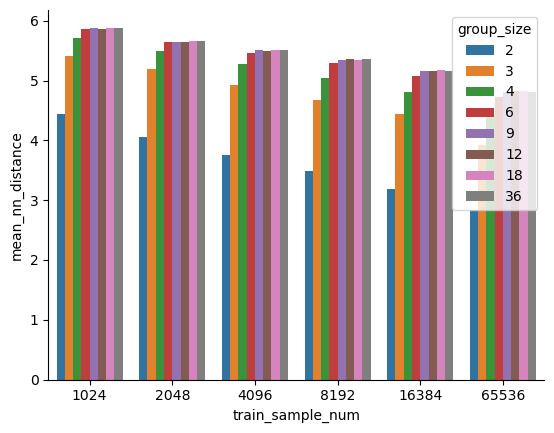

In [100]:
sns.barplot(x="train_sample_num", y="mean_nn_distance", hue="group_size", 
            data=nn_analysis_df, palette="tab10", 
            hue_order=[2, 3, 4, 6, 9, 12, 18, 36])
plt.show()

### Scaling of nearest neighbor relation with sample size

Group size 2: y = -0.2669 * log2(N) + 7.0104, R² = 0.9827


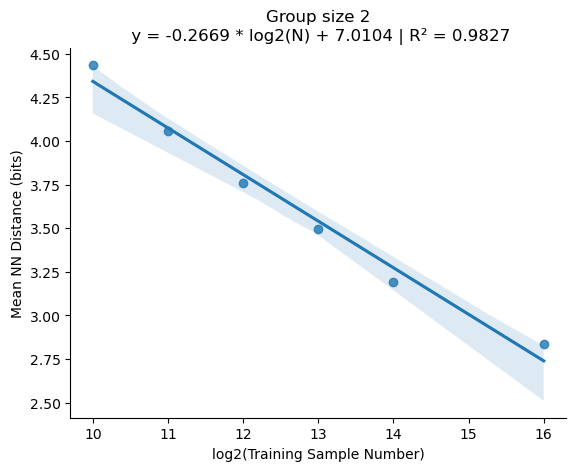

Group size 3: y = -0.2487 * log2(N) + 7.9090, R² = 0.9997


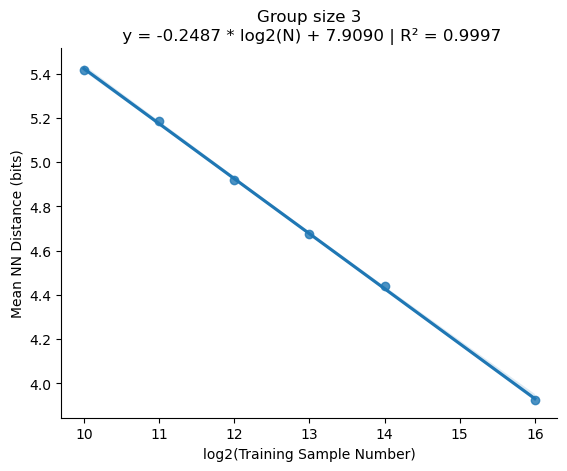

Group size 4: y = -0.2160 * log2(N) + 7.8623, R² = 0.9986


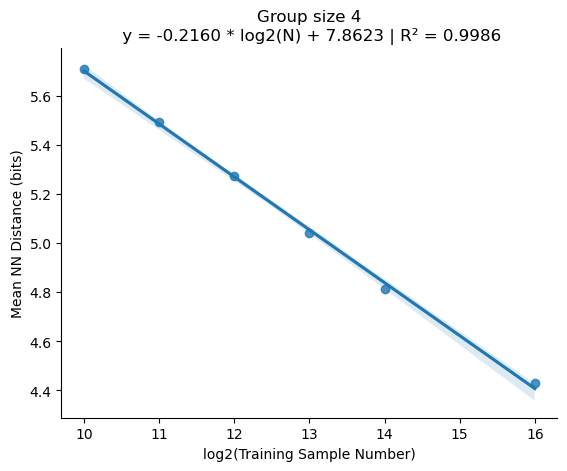

Group size 6: y = -0.1876 * log2(N) + 7.7193, R² = 0.9991


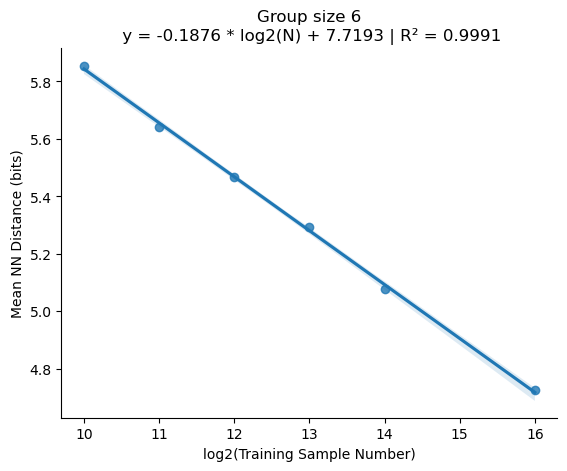

Group size 9: y = -0.1738 * log2(N) + 7.5906, R² = 0.9972


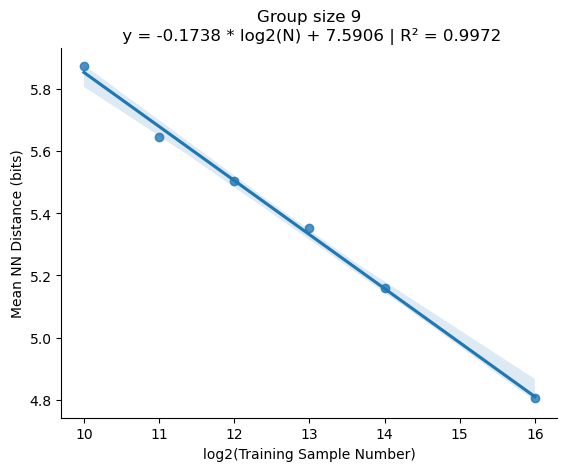

Group size 12: y = -0.1706 * log2(N) + 7.5503, R² = 0.9976


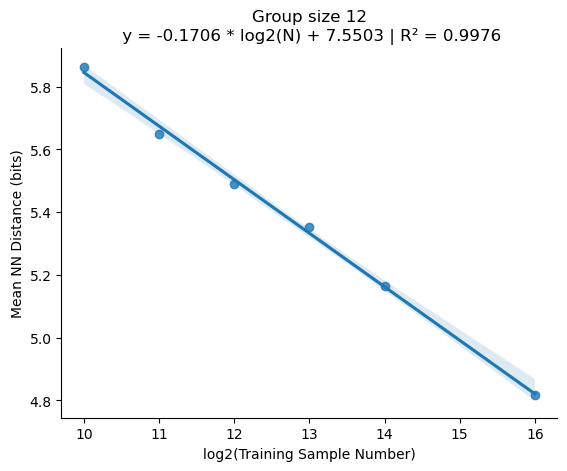

Group size 18: y = -0.1736 * log2(N) + 7.5966, R² = 0.9985


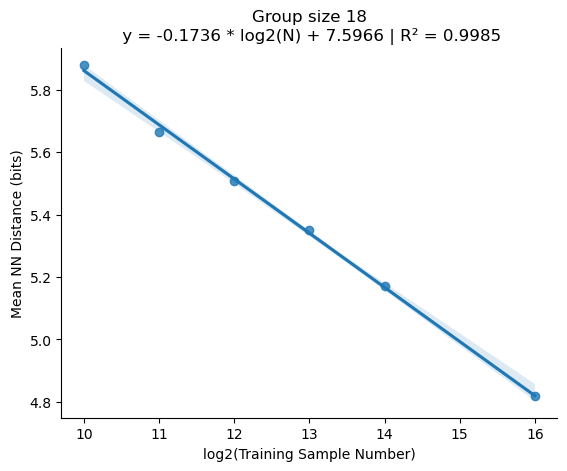

Group size 36: y = -0.1751 * log2(N) + 7.6189, R² = 0.9977


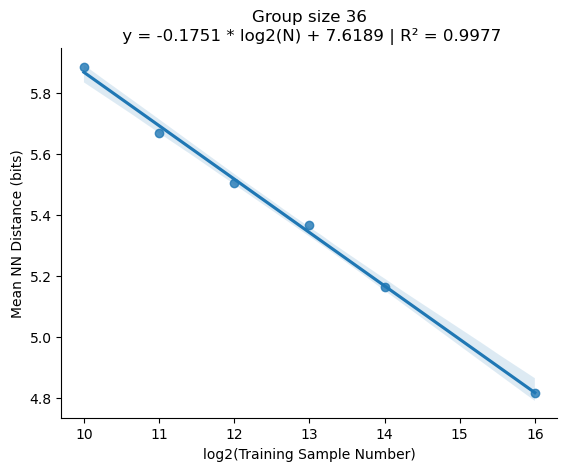

In [ ]:
from sklearn.linear_model import LinearRegression
# Fit the relationship between train sample num and mean nn distance for each group size
for group_size in [2, 3, 4, 6, 9, 12, 18, 36]:
    df = nn_analysis_df.query("group_size == @group_size")
    # Prepare data for regression
    x = np.log2(df["train_sample_num"].astype(float))
    y = df["mean_nn_distance"].astype(float)
    # Fit linear regression
    reg = LinearRegression()
    reg.fit(x.values.reshape(-1, 1), y.values)
    # Calculate R-squared
    r_squared = reg.score(x.values.reshape(-1, 1), y.values)
    # Print regression equation
    print(f"Group size {group_size}: y = {reg.coef_[0]:.4f} * log2(N) + {reg.intercept_:.4f}, R² = {r_squared:.4f}")
    # Plot
    sns.regplot(x=x, y=y, data=df)
    plt.title(f"Group size {group_size}\n y = {reg.coef_[0]:.4f} * log2(N) + {reg.intercept_:.4f} | R² = {r_squared:.4f}")
    plt.xlabel("log2(Training Sample Number)")
    plt.ylabel("Mean NN Distance (bits)")
    plt.show()

Group size 2: log2(1 / d_NN) = 0.1083 * log2(N) + -3.2161, R² = 0.9951
Group size 3: log2(1 / d_NN) = 0.0773 * log2(N) + -3.2223, R² = 0.9965
Group size 4: log2(1 / d_NN) = 0.0618 * log2(N) + -3.1355, R² = 0.9993
Group size 6: log2(1 / d_NN) = 0.0514 * log2(N) + -3.0650, R² = 0.9987
Group size 9: log2(1 / d_NN) = 0.0472 * log2(N) + -3.0245, R² = 0.9963
Group size 12: log2(1 / d_NN) = 0.0463 * log2(N) + -3.0133, R² = 0.9970
Group size 18: log2(1 / d_NN) = 0.0470 * log2(N) + -3.0248, R² = 0.9980
Group size 36: log2(1 / d_NN) = 0.0474 * log2(N) + -3.0306, R² = 0.9970


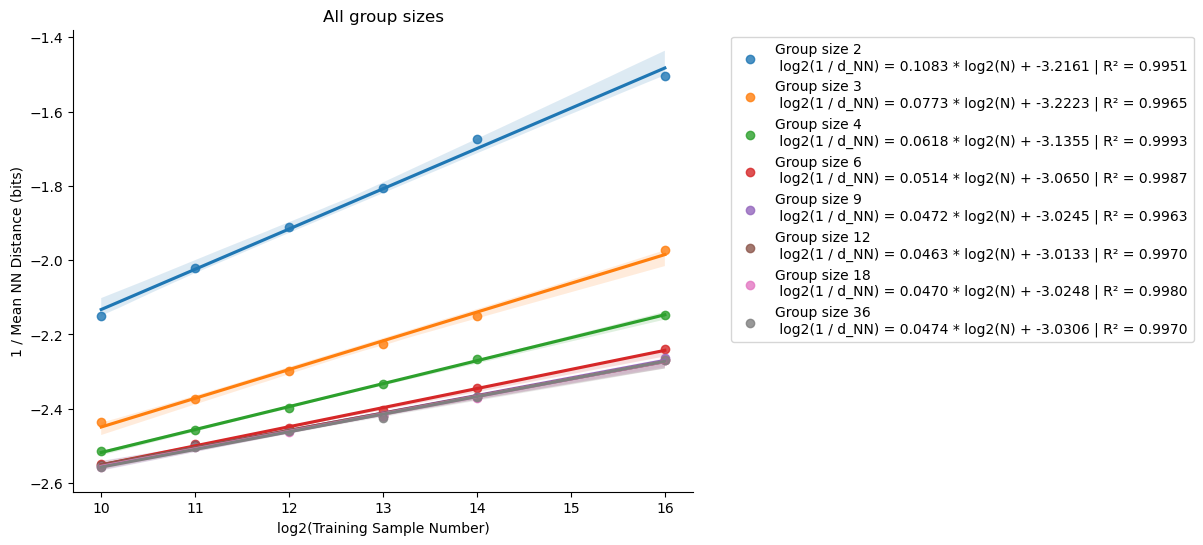

In [112]:
from sklearn.linear_model import LinearRegression
# Fit the relationship between train sample num and mean nn distance for each group size
fig, ax = plt.subplots(figsize=(8, 6))
for group_size in [2, 3, 4, 6, 9, 12, 18, 36]:
    df = nn_analysis_df.query("group_size == @group_size")
    # Prepare data for regression
    x = np.log2(df["train_sample_num"].astype(float))
    y = np.log2(1 / df["mean_nn_distance"].astype(float))
    # Fit linear regression
    reg = LinearRegression()
    reg.fit(x.values.reshape(-1, 1), y.values)
    # Calculate R-squared
    r_squared = reg.score(x.values.reshape(-1, 1), y.values)
    # Print regression equation
    print(f"Group size {group_size}: log2(1 / d_NN) = {reg.coef_[0]:.4f} * log2(N) + {reg.intercept_:.4f}, R² = {r_squared:.4f}")
    # Plot
    sns.regplot(x=x, y=y, data=df, label=f"Group size {group_size}\n log2(1 / d_NN) = {reg.coef_[0]:.4f} * log2(N) + {reg.intercept_:.4f} | R² = {r_squared:.4f}")
plt.title("All group sizes")
plt.xlabel("log2(Training Sample Number)")
plt.ylabel("1 / Mean NN Distance (bits)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Group size 2: log2(1 / d_NN) = 0.1083 * log2(N) + -3.2161, R² = 0.9951


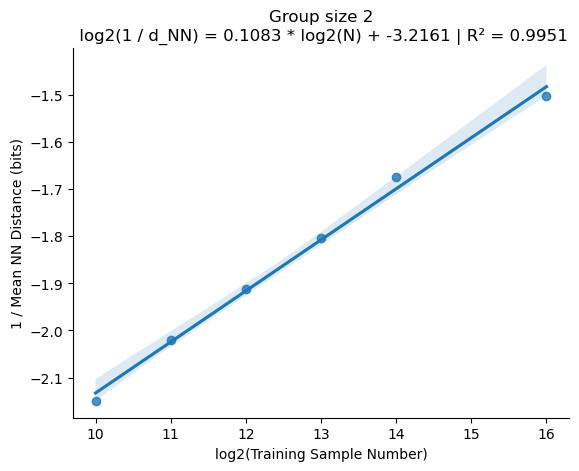

Group size 3: log2(1 / d_NN) = 0.0773 * log2(N) + -3.2223, R² = 0.9965


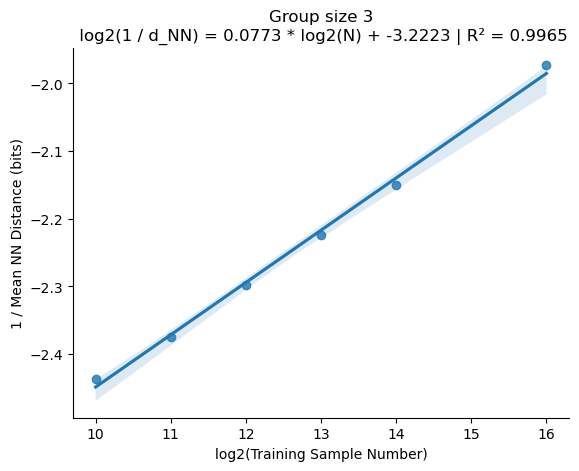

Group size 4: log2(1 / d_NN) = 0.0618 * log2(N) + -3.1355, R² = 0.9993


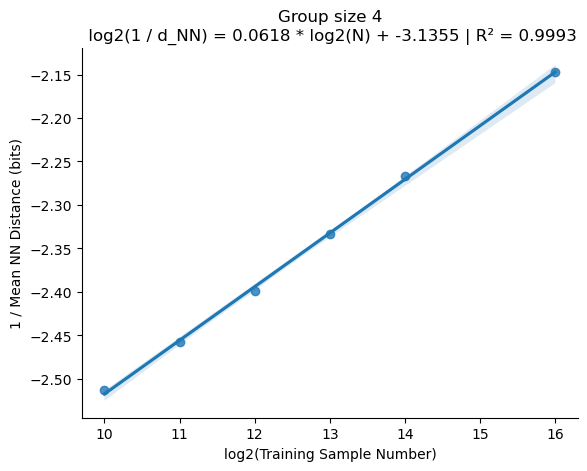

Group size 6: log2(1 / d_NN) = 0.0514 * log2(N) + -3.0650, R² = 0.9987


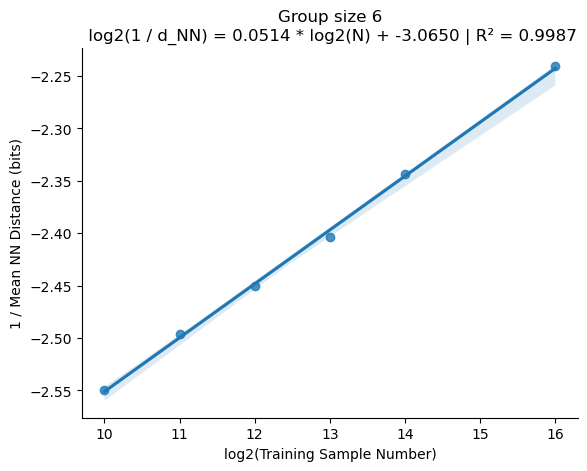

Group size 9: log2(1 / d_NN) = 0.0472 * log2(N) + -3.0245, R² = 0.9963


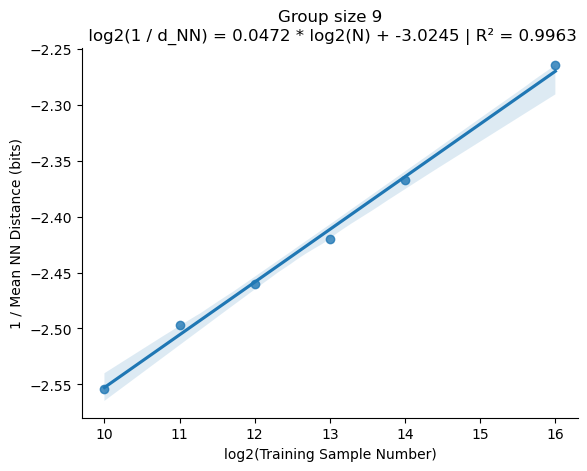

Group size 12: log2(1 / d_NN) = 0.0463 * log2(N) + -3.0133, R² = 0.9970


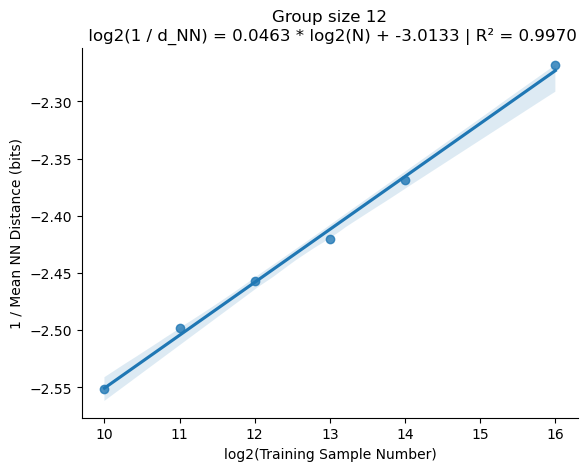

Group size 18: log2(1 / d_NN) = 0.0470 * log2(N) + -3.0248, R² = 0.9980


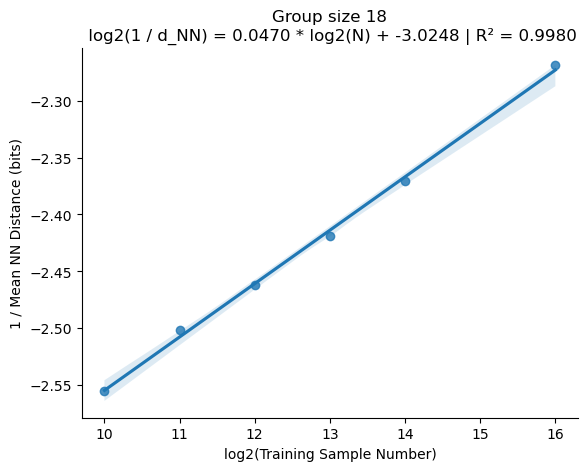

Group size 36: log2(1 / d_NN) = 0.0474 * log2(N) + -3.0306, R² = 0.9970


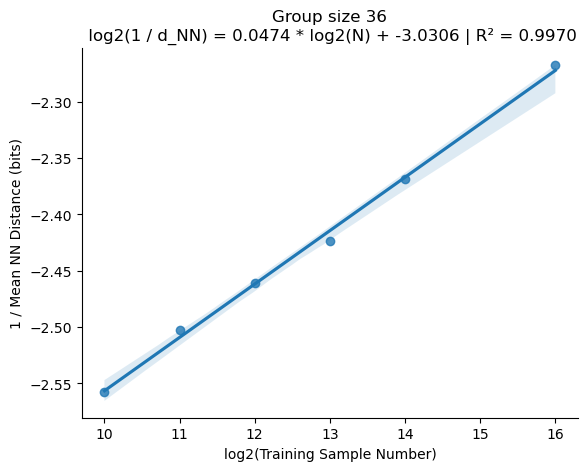

In [110]:
from sklearn.linear_model import LinearRegression
# Fit the relationship between train sample num and mean nn distance for each group size
for group_size in [2, 3, 4, 6, 9, 12, 18, 36]:
    df = nn_analysis_df.query("group_size == @group_size")
    # Prepare data for regression
    x = np.log2(df["train_sample_num"].astype(float))
    y = np.log2(1 / df["mean_nn_distance"].astype(float))
    # Fit linear regression
    reg = LinearRegression()
    reg.fit(x.values.reshape(-1, 1), y.values)
    # Calculate R-squared
    r_squared = reg.score(x.values.reshape(-1, 1), y.values)
    # Print regression equation
    print(f"Group size {group_size}: log2(1 / d_NN) = {reg.coef_[0]:.4f} * log2(N) + {reg.intercept_:.4f}, R² = {r_squared:.4f}")
    # Plot
    sns.regplot(x=x, y=y, data=df)
    plt.title(f"Group size {group_size}\n log2(1 / d_NN) = {reg.coef_[0]:.4f} * log2(N) + {reg.intercept_:.4f} | R² = {r_squared:.4f}")
    plt.xlabel("log2(Training Sample Number)")
    plt.ylabel("1 / Mean NN Distance (bits)")
    plt.show()

In [ ]:
# Summary statistics and visualizations for nearest neighbor distances
print("=== NEAREST NEIGHBOR DISTANCE ANALYSIS SUMMARY ===")
print(f"Analyzed {len(nn_analysis_df)} experiments")
print(f"\nNearest neighbor distance statistics (in bits):")
print(f"  Mean NN distance: {nn_analysis_df['mean_nn_distance'].mean():.3f} ± {nn_analysis_df['mean_nn_distance'].std():.3f}")
print(f"  Min NN distance:  {nn_analysis_df['min_nn_distance'].mean():.3f} ± {nn_analysis_df['min_nn_distance'].std():.3f}")
print(f"  Max NN distance:  {nn_analysis_df['max_nn_distance'].mean():.3f} ± {nn_analysis_df['max_nn_distance'].std():.3f}")

# Group by key parameters
print(f"\nGrouped by sample size:")
grouped = nn_analysis_df.groupby('train_sample_num')['mean_nn_distance'].agg(['mean', 'std', 'count'])
print(grouped)

print(f"\nGrouped by group size:")
grouped = nn_analysis_df.groupby('group_size')['mean_nn_distance'].agg(['mean', 'std', 'count'])
print(grouped)

In [ ]:
# Visualize nearest neighbor distances
plt.figure(figsize=(15, 5))

# Plot 1: NN distance vs sample size
plt.subplot(1, 3, 1)
sns.scatterplot(data=nn_analysis_df, x='train_sample_num', y='mean_nn_distance', 
                hue='group_size', size='group_size', alpha=0.7)
plt.xscale('log')
plt.xlabel('Training Sample Number')
plt.ylabel('Mean NN Distance (bits)')
plt.title('NN Distance vs Sample Size')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: NN distance vs group size
plt.subplot(1, 3, 2)
sns.boxplot(data=nn_analysis_df, x='group_size', y='mean_nn_distance')
plt.xlabel('Group Size')
plt.ylabel('Mean NN Distance (bits)')
plt.title('NN Distance vs Group Size')

# Plot 3: Distribution of NN distances
plt.subplot(1, 3, 3)
plt.hist(nn_analysis_df['mean_nn_distance'], bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Mean NN Distance (bits)')
plt.ylabel('Frequency')
plt.title('Distribution of NN Distances')

plt.tight_layout()
plt.show()

# Save the analysis results
nn_analysis_df.to_csv(join(saveroot, "nn_distance_analysis.csv"), index=False)
print(f"Saved NN analysis results to {join(saveroot, 'nn_distance_analysis.csv')}")